# LongVerse figures

Every panel below is drawn from a small file in `data/`. Nothing here reads a BAM or a
whole-genome table, which is why it runs in a browser.

Run all cells: **Run -> Run All Cells**. The figures appear inline and are also written to
`figures/` as PDF and PNG.


In [1]:
import sys; sys.path.insert(0, "../scripts")
from pathlib import Path
import matplotlib.pyplot as plt
import panels as P

P.style()
D = Path("../data"); OUT = Path("../figures"); OUT.mkdir(exist_ok=True)

def save(ax, name):
    fig = ax.figure
    fig.tight_layout()
    for ext in ("pdf", "png"):
        fig.savefig(OUT / f"{name}.{ext}", bbox_inches="tight")
    return fig


## Figure 1e. Three callers and their consensus against whole-genome bisulfite sequencing

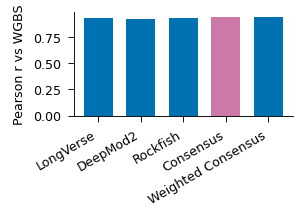

In [2]:
ax = P.bars(D/"fig1/e_consensus_vs_wgbs.csv", "series", "pearson_r_vs_wgbs",
            "", "Pearson r vs WGBS", highlight="Consensus")
save(ax, "fig1e_consensus");

## Figure 1f. The same comparison split by read depth

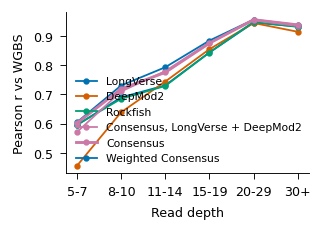

In [3]:
ax = P.lines_by_series(D/"fig1/f_consensus_by_coverage.csv", "coverage_bin",
                       "pearson_r_vs_wgbs", "series", "Read depth",
                       "Pearson r vs WGBS", highlight="Consensus")
save(ax, "fig1f_by_coverage");

## Figure 2b. Mean methylation around transcription start sites, expert and agent

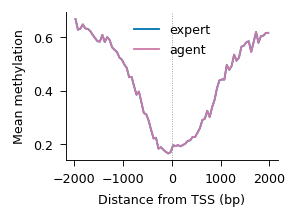

In [4]:
ax = P.profile(D/"fig2/b_tss_profile.csv",
               {"human": ("expert", P.ONT_C), "agent_mcp_prompt": ("agent", P.HYPER)},
               "Distance from TSS (bp)", "Mean methylation")
save(ax, "fig2b_tss");

## Figure 2b. Per-site agreement with WGBS\nThe two arms agree with each other exactly: the agent reproduced the expert's run.

In [5]:
import pandas as pd
print(pd.read_csv(D/"fig2/b_persite_vs_wgbs.csv").to_string(index=False))

    comparison  pearson_r  p_value  n_sites  min_cov_longread wgbs_filter    strands
 human_vs_wgbs   0.942923      0.0  1540012                 5        none not_merged
 agent_vs_wgbs   0.942923      0.0  1540012                 5        none not_merged
human_vs_agent   1.000000      0.0  1575278                 5        none not_merged


## Figure 2c. Haplotype methylation at the chromosome 20 imprinting control regions

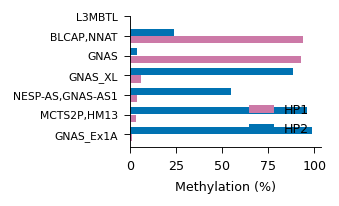

In [6]:
ax = P.icr_haplotypes(D/"fig2/c_icr_by_region.csv", arm="human")
save(ax, "fig2c_icr");

## Extended Data Fig. 1a. Agreement with WGBS by read depth, both arms

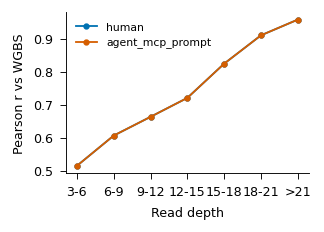

In [7]:
ax = P.lines_by_series(D/"ed_fig1/a_wgbs_by_coverage.csv", "cov_bin", "PCC", "arm",
                       "Read depth", "Pearson r vs WGBS")
save(ax, "ed1a_by_coverage");

## Extended Data Fig. 1d. Transcription start site profile after phasing

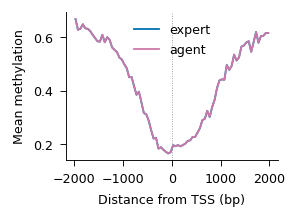

In [8]:
ax = P.profile(D/"ed_fig1/d_tss_after_phasing.csv",
               {"human_command_line": ("expert", P.ONT_C), "agent": ("agent", P.HYPER)},
               "Distance from TSS (bp)", "Mean methylation")
save(ax, "ed1d_tss");

## Extended Data Fig. 1c. The agent arm at the same imprinting control regions

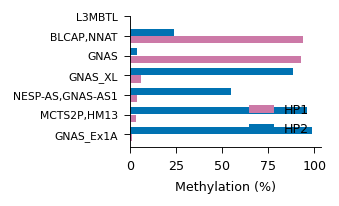

In [9]:
ax = P.icr_haplotypes(D/"ed_fig1/c_icr_by_region.csv", arm="agent")
save(ax, "ed1c_icr");

## Extended Data Fig. 4a-c. Per-site methylation, every pair of platforms\nEach hexagon is one the original panel computed, exported from 56 to 62 million sites.

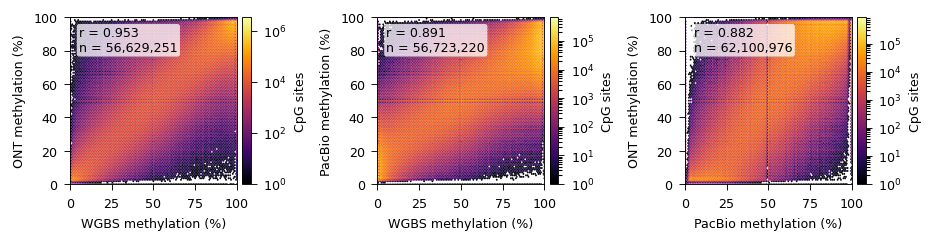

In [10]:
specs = [("ed4_a_ont_vs_wgbs", "a_ont_vs_wgbs", "WGBS methylation (%)", "ONT methylation (%)"),
         ("ed4_b_pacbio_vs_wgbs", "b_pacbio_vs_wgbs", "WGBS methylation (%)", "PacBio methylation (%)"),
         ("ed4_c_ont_vs_pacbio", "c_ont_vs_pacbio", "PacBio methylation (%)", "ONT methylation (%)")]
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.3))
for (key, stem, xl, yl), ax in zip(specs, axes):
    st = P.read_hexbin_stats(D/f"ed_fig4/hexbin_{stem}_nm_stats.txt")
    P.hexbin(key, xl, yl, st, ax=ax)
save(axes[0], "ed4abc_hexbins");

## Extended Data Fig. 4d,e. Haplotype DMRs along the autosomes\nDrawn at |HP1 - HP2| >= 50 percentage points and q <= 0.01, the same cutoff as the paper.

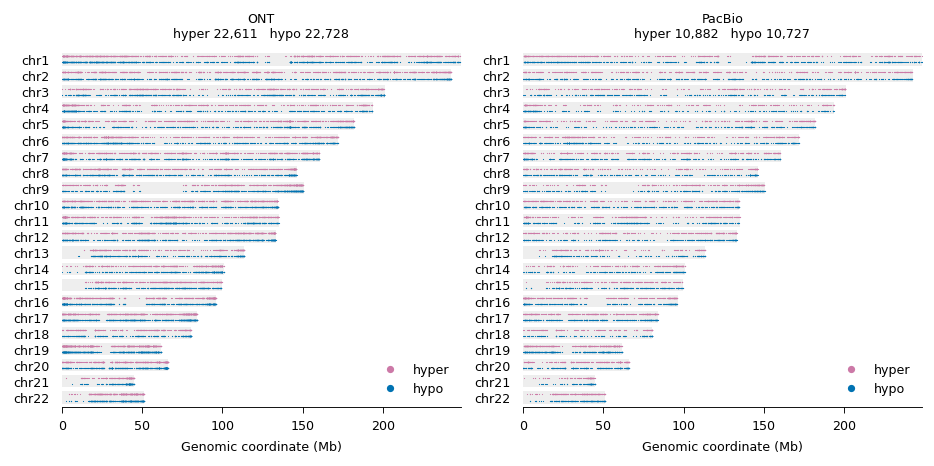

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.6))
P.ideogram("ed4_d_ont", "ONT", ax=axes[0])
P.ideogram("ed4_e_pacbio", "PacBio", ax=axes[1])
save(axes[0], "ed4de_ideograms");

## Extended Data Fig. 4f,g. Imprinting control regions, HP1 minus HP2

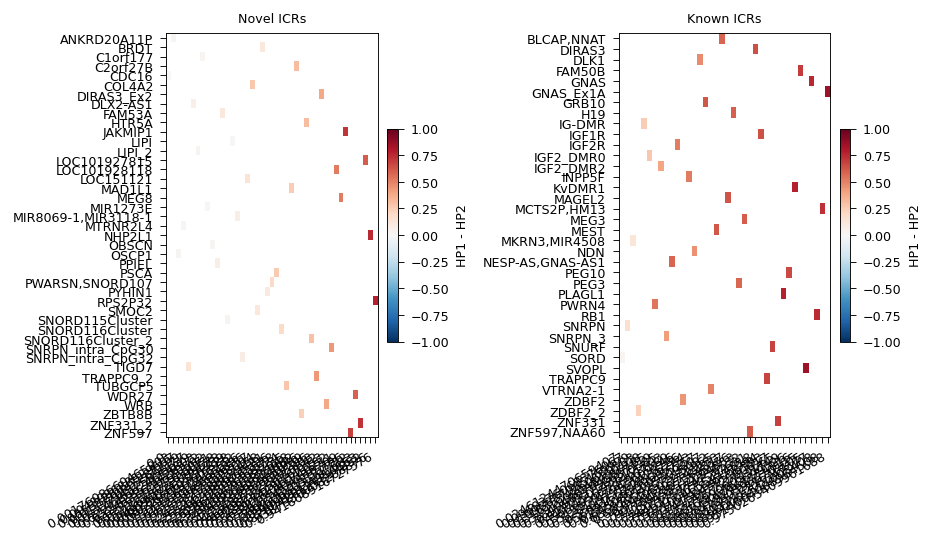

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 4.2))
P.heatmap(D/"ed_fig4/icr_heatmap_novel_nm.plotdf.csv", "Novel ICRs", ax=axes[0])
P.heatmap(D/"ed_fig4/icr_heatmap_known_nm.plotdf.csv", "Known ICRs", ax=axes[1])
save(axes[0], "ed4fg_icr_heatmaps");

## Extended Data Fig. 5d,e. Methylation around TSS and CTCF sites, three platforms

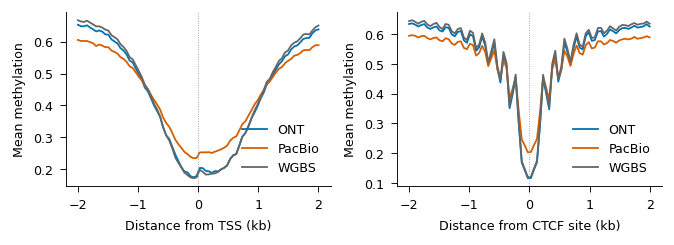

In [13]:
cols = {"ONT": ("ONT", P.ONT_C), "PacBio": ("PacBio", P.PB_C), "WGBS": ("WGBS", P.WGBS_C)}
fig, axes = plt.subplots(1, 2, figsize=(5.2, 1.9))
P.profile_deeptools(D/"ed_fig5/TSS_profile_3track_nozero_data.tsv", cols,
                    "Distance from TSS (kb)", "Mean methylation", ax=axes[0])
P.profile_deeptools(D/"ed_fig5/CTCF_profile_3track_nozero_data.tsv", cols,
                    "Distance from CTCF site (kb)", "Mean methylation", ax=axes[1])
save(axes[0], "ed5de_profiles");

## Extended Data Fig. 5f. ONT against PacBio within eight genomic region classes

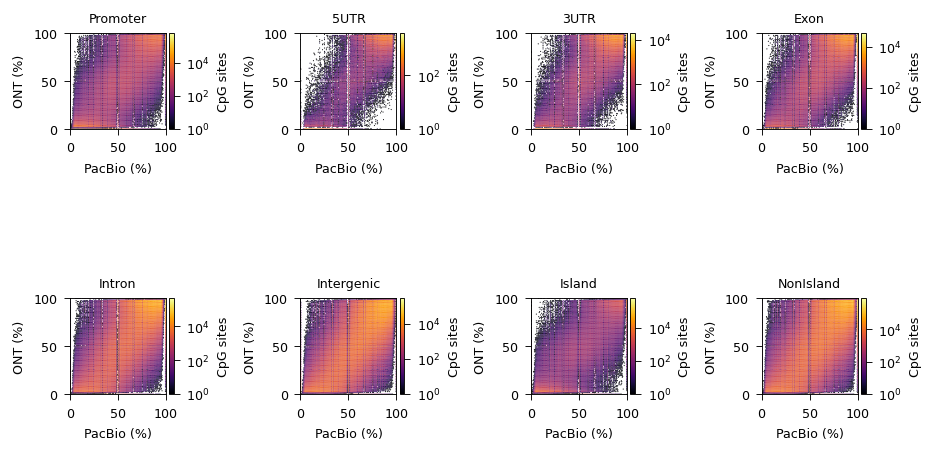

In [14]:
regions = ["Promoter", "5UTR", "3UTR", "Exon", "Intron", "Intergenic", "Island", "NonIsland"]
fig, axes = plt.subplots(2, 4, figsize=(7.2, 4.2))
for reg, ax in zip(regions, axes.ravel()):
    P.hexbin(f"ed5_f_{reg}", "PacBio (%)", "ONT (%)", ax=ax)
    ax.set_title(reg)
save(axes.ravel()[0], "ed5f_region_hexbins");